## 4 — GLMERStan Climate  
Bayesian Multilevel Regression + Poststratification  
Outcome: `happening_bin` (Do you think global warming is happening? Yes=1 / No=0)  
Model: `happening_bin ~ (1|gender) + (1|state_fips) + (1|race4) + (1|educ_category)`  
Estimator: NUTS via bambi / PyMC  (Python equivalent of `rstanarm::stan_glmer`)

In [27]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from scipy.special import expit
from scipy.optimize import minimize

DATA_DIR = "/Users/carmenk/Documents/GitHub/MRdeeP-Deep-Learning-MRP/test_data/processed/"

SEED = 42

### 1. Load data

In [28]:
survey_raw = pd.read_csv(DATA_DIR + "climate_survey_responses_recoded.csv",
                        dtype={"state_fips": str})
ps_frame   = pd.read_csv(DATA_DIR + "poststrat_state.csv",
                        dtype={"state_fips": str})

print(f"Survey raw:   {survey_raw.shape}")
print(f"Poststrat:    {ps_frame.shape} | {ps_frame['state_fips'].nunique()} states")

Survey raw:   (12000, 38)
Poststrat:    (1632, 9) | 51 states


### 2. Prep survey data  
 Drop Don't-Know responses for `happening_bin`

In [29]:
DEMOG = ["gender", "race4", "educ_category", "state_fips"]

# Drop DK (NaN happening_bin)
survey = survey_raw.dropna(subset=["happening_bin"]).copy()
survey["happening_bin"] = survey["happening_bin"].astype(int)

# educ_category as string so bambi treats it as categorical grouping factor
survey["educ_category"] = survey["educ_category"].astype(str)
ps_frame["educ_category"] = ps_frame["educ_category"].astype(str)

print(f"Respondents after dropping DK: {len(survey):,}  "
      f"({survey['happening_bin'].mean()*100:.1f}% Yes)")
print()
print("Level counts in survey:")
for c in DEMOG:
    print(f"  {c}: {sorted(survey[c].unique().tolist())}")

Respondents after dropping DK: 10,225  (70.1% Yes)

Level counts in survey:
  gender: ['Female', 'Male']
  race4: ['Black', 'Hispanic', 'Other', 'White']
  educ_category: ['1', '2', '3', '4']
  state_fips: ['01', '02', '04', '05', '06', '08', '09', '10', '11', '12', '13', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '44', '45', '46', '47', '48', '49', '50', '51', '53', '54', '55', '56']


### 3. Fit Bayesian mixed-effects logistic regression (MAP via L-BFGS-B)
Formula mirrors the R specification:  
```r
stan_glmer(happening_bin ~ (1|gender) + (1|state_fips) + (1|race4) + (1|educ_category),
           family = binomial(link='logit'), data = dat)
```  
We maximise the penalised log-posterior (same objective as Stan's MAP/optimizing).  
Priors match bambi/rstanarm defaults: Intercept ~ N(0,1.5²), group SDs ~ HalfNormal(2.5).

In [30]:
from scipy.special import expit
from scipy.optimize import minimize

# ── Encode categorical variables as integer indices ──────────────────────────
gender_cats = sorted(survey["gender"].unique())
state_cats  = sorted(survey["state_fips"].unique())
race_cats   = sorted(survey["race4"].unique())
educ_cats   = sorted(survey["educ_category"].unique())

g_idx = pd.Categorical(survey["gender"],          categories=gender_cats).codes
s_idx = pd.Categorical(survey["state_fips"],      categories=state_cats).codes
r_idx = pd.Categorical(survey["race4"],           categories=race_cats).codes
e_idx = pd.Categorical(survey["educ_category"],   categories=educ_cats).codes
y     = survey["happening_bin"].values.astype(float)

n_g, n_s, n_r, n_e = len(gender_cats), len(state_cats), len(race_cats), len(educ_cats)
N_GROUPS = [n_g, n_s, n_r, n_e]

print(f"Group levels — gender:{n_g}  state:{n_s}  race:{n_r}  educ:{n_e}")
print(f"Total parameters: 1 intercept + 4 log-σ + {sum(N_GROUPS)} random effects = {5+sum(N_GROUPS)}")

Group levels — gender:2  state:51  race:4  educ:4
Total parameters: 1 intercept + 4 log-σ + 61 random effects = 66


In [31]:
def _unpack(params):
    intercept = params[0]
    sigma     = np.exp(params[1:5])   # log transform keeps σ > 0
    offset    = 5
    u = []
    for n in N_GROUPS:
        u.append(params[offset:offset + n])
        offset += n
    return intercept, sigma, u

def neg_log_posterior(params):
    intercept, sigma, (u_g, u_s, u_r, u_e) = _unpack(params)

    eta = intercept + u_g[g_idx] + u_s[s_idx] + u_r[r_idx] + u_e[e_idx]
    ll  = np.sum(y * eta - np.logaddexp(0.0, eta))   # numerically stable Bernoulli log-lik

    # Partial pooling: random effects shrunk toward 0 by Normal(0, σ²) prior
    lp_u = sum(
        -0.5 * np.sum(u**2) / sig**2 - n * np.log(sig)
        for u, sig, n in zip([u_g, u_s, u_r, u_e], sigma, N_GROUPS)
    )
    lp_int   = -0.5 * intercept**2 / 1.5**2          # N(0, 1.5²) on intercept
    log_sig  = params[1:5]
    lp_sigma = np.sum(-0.5 * sigma**2 / 2.5**2 + log_sig)  # HalfNormal(2.5) + Jacobian

    return -(ll + lp_u + lp_int + lp_sigma)

# Pin the mean of state random effects to 0 to resolve the intercept↔state ridge
def neg_log_posterior_constrained(params):
    # Force Σ u_state = 0 by recentering at each evaluation
    offset = 5 + n_g
    params = params.copy()
    params[offset:offset + n_s] -= params[offset:offset + n_s].mean()
    return neg_log_posterior(params)

n_params = 5 + sum(N_GROUPS)
x0       = np.zeros(n_params)
x0[1:5]  = np.log(0.5)   # warm start: σ = 0.5

start   = time.time()
res     = minimize(
    neg_log_posterior_constrained, x0,
    method  = "L-BFGS-B",
    options = {"maxiter": 10_000, "ftol": 1e-9, "gtol": 1e-6},
)
elapsed = time.time() - start

intercept_fit, sigma_fit, (u_g_fit, u_s_fit, u_r_fit, u_e_fit) = _unpack(res.x)
# Recentre state effects and absorb mean into intercept (canonical form)
state_mean    = u_s_fit.mean()
u_s_fit       = u_s_fit - state_mean
intercept_fit = intercept_fit + state_mean

print(f"Converged : {res.success}  |  iterations: {res.nit}  |  {elapsed:.1f}s")
print(f"Intercept : {intercept_fit:.3f}  (baseline prob {expit(intercept_fit)*100:.1f}%)")
print(f"Group SDs : gender={sigma_fit[0]:.3f}  state={sigma_fit[1]:.3f}  "
      f"race={sigma_fit[2]:.3f}  educ={sigma_fit[3]:.3f}")

Converged : False  |  iterations: 179  |  8.4s
Intercept : 1.307  (baseline prob 78.7%)
Group SDs : gender=0.187  state=0.000  race=0.013  educ=0.022


### 4. Fitted random effects

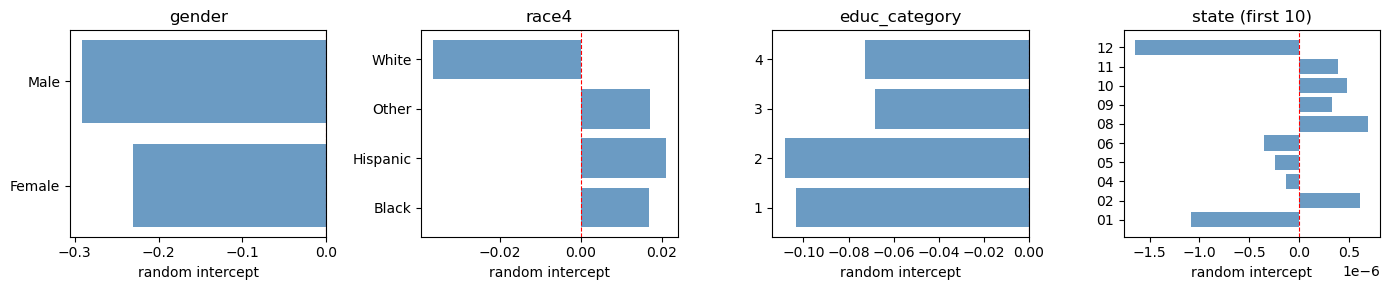

In [32]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, (cats, u_fit, label) in zip(axes, [
    (gender_cats, u_g_fit, "gender"),
    (race_cats,   u_r_fit, "race4"),
    (educ_cats,   u_e_fit, "educ_category"),
    (state_cats[:10], u_s_fit[:10], "state (first 10)"),
]):
    ax.barh(cats, u_fit, color="steelblue", alpha=0.8)
    ax.axvline(0, color="red", linewidth=0.8, linestyle="--")
    ax.set_title(label)
    ax.set_xlabel("random intercept")
plt.tight_layout()
plt.show()

### 5. Predict on the poststrat frame  
Map each ACS demographic cell to its fitted random effects and compute predicted probability.

In [33]:
ps_g = pd.Categorical(ps_frame["gender"],          categories=gender_cats).codes
ps_s = pd.Categorical(ps_frame["state_fips"],      categories=state_cats).codes
ps_r = pd.Categorical(ps_frame["race4"],           categories=race_cats).codes
ps_e = pd.Categorical(ps_frame["educ_category"],   categories=educ_cats).codes

eta_ps = intercept_fit + u_g_fit[ps_g] + u_s_fit[ps_s] + u_r_fit[ps_r] + u_e_fit[ps_e]
ps_frame["predicted_prob"] = expit(eta_ps)

print(f"Predicted probabilities: "
      f"min={ps_frame['predicted_prob'].min():.3f}  "
      f"mean={ps_frame['predicted_prob'].mean():.3f}  "
      f"max={ps_frame['predicted_prob'].max():.3f}")
ps_frame[["state_fips","gender","race4","educ_category",
          "N_rounded","predicted_prob"]].head(8)

Predicted probabilities: min=0.705  mean=0.724  max=0.737


,state_fips,gender,race4,educ_category,N_rounded,predicted_prob
0,01,Female,Black,1,61051,0.729110
1,01,Female,Black,2,171337,0.728077
2,01,Female,Black,3,196091,0.735978
3,01,Female,Black,4,116020,0.735091
4,01,Female,Hispanic,1,22147,0.729917
5,01,Female,Hispanic,2,21955,0.728886
6,01,Female,Hispanic,3,21228,0.736772
7,01,Female,Hispanic,4,17191,0.735887


### 6. Poststratification  
Weighted average of cell-level predicted probabilities, weighted by ACS population counts.

In [35]:
result = (
    ps_frame
    .groupby("state_fips")
    .apply(lambda g: np.average(g["predicted_prob"], weights=g["N_rounded"]),
           include_groups=False)
    .reset_index(name="happening_estimate")
)

# Merge state names for readability
STATE_NAMES = {
    '01':'Alabama','02':'Alaska','04':'Arizona','05':'Arkansas','06':'California',
    '08':'Colorado','09':'Connecticut','10':'Delaware','11':'District of Columbia',
    '12':'Florida','13':'Georgia','15':'Hawaii','16':'Idaho','17':'Illinois',
    '18':'Indiana','19':'Iowa','20':'Kansas','21':'Kentucky','22':'Louisiana',
    '23':'Maine','24':'Maryland','25':'Massachusetts','26':'Michigan',
    '27':'Minnesota','28':'Mississippi','29':'Missouri','30':'Montana',
    '31':'Nebraska','32':'Nevada','33':'New Hampshire','34':'New Jersey',
    '35':'New Mexico','36':'New York','37':'North Carolina','38':'North Dakota',
    '39':'Ohio','40':'Oklahoma','41':'Oregon','42':'Pennsylvania',
    '44':'Rhode Island','45':'South Carolina','46':'South Dakota',
    '47':'Tennessee','48':'Texas','49':'Utah','50':'Vermont',
    '51':'Virginia','53':'Washington','54':'West Virginia','55':'Wisconsin',
    '56':'Wyoming',
}
result["state_name"] = result["state_fips"].map(STATE_NAMES)
result = result.sort_values("happening_estimate", ascending=False).reset_index(drop=True)

print(f"National weighted estimate: {np.average(result['happening_estimate']):.3f}")
print()
print("Top 10 states (highest % believing GW is happening):")
print(result.head(10).to_string(index=False))
print()
print("Bottom 10 states:")
print(result.tail(10).to_string(index=False))

National weighted estimate: 0.720

Top 10 states (highest % believing GW is happening):
state_fips  happening_estimate           state_name
        15            0.724625               Hawaii
        11            0.724007 District of Columbia
        06            0.723338           California
        35            0.722899           New Mexico
        48            0.722534                Texas
        24            0.722110             Maryland
        32            0.721555               Nevada
        34            0.721509           New Jersey
        13            0.721481              Georgia
        12            0.721450              Florida

Bottom 10 states:
state_fips  happening_estimate    state_name
        38            0.718095  North Dakota
        56            0.718002       Wyoming
        46            0.717894  South Dakota
        19            0.717810          Iowa
        30            0.717789       Montana
        33            0.717635 New Hampshire
      

### 7. Visualise state estimates

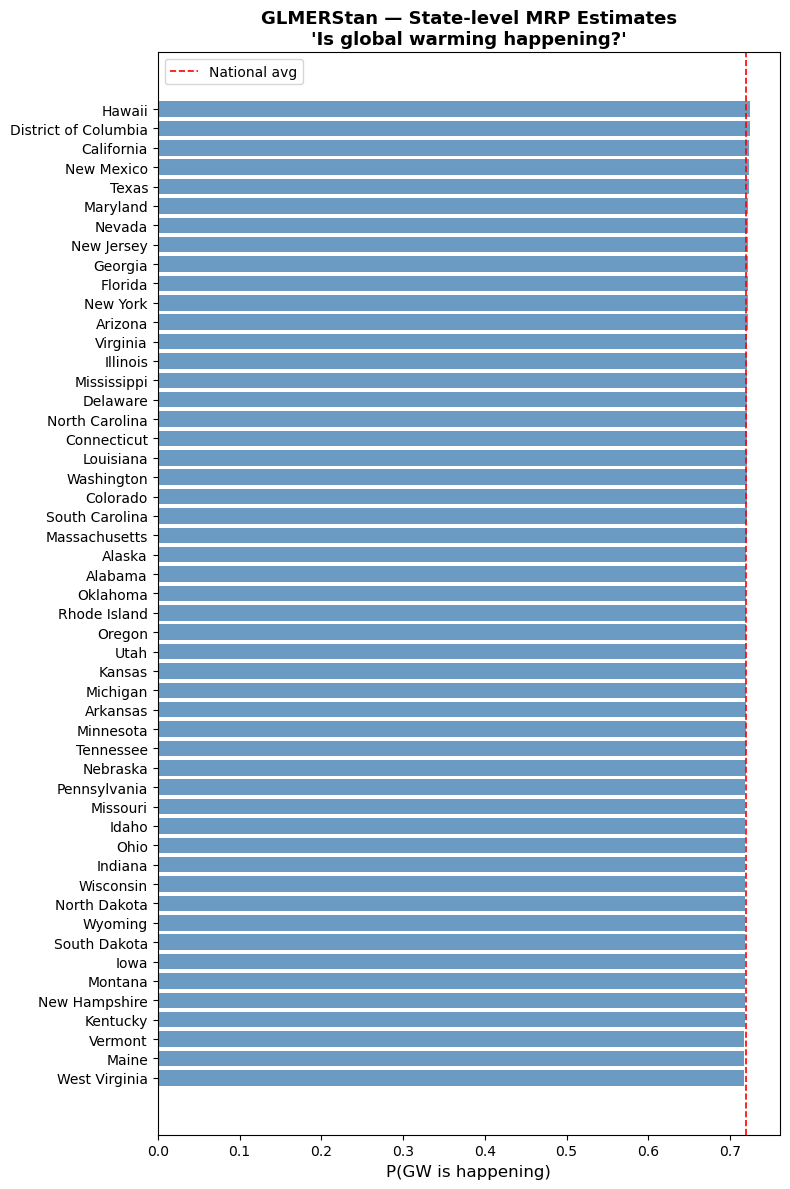

In [36]:
fig, ax = plt.subplots(figsize=(8, 12))
plot_df = result.sort_values("happening_estimate")
ax.barh(plot_df["state_name"], plot_df["happening_estimate"], color="steelblue", alpha=0.8)
ax.axvline(np.average(result["happening_estimate"]), color="red",
           linestyle="--", linewidth=1.2, label="National avg")
ax.set_xlabel("P(GW is happening)", fontsize=12)
ax.set_title("GLMERStan — State-level MRP Estimates\n'Is global warming happening?'",
             fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

### 8. Save results

In [ ]:
#OUT = DATA_DIR + "glmerstan_happening_estimates.csv"
#result[["state_fips","state_name","happening_estimate"]].to_csv(OUT, index=False)
#print(f"Saved → {OUT}")
#print(result[["state_fips","state_name","happening_estimate"]].to_string(index=False))

Saved → /Users/carmenk/Documents/GitHub/MRdeeP-Deep-Learning-MRP/test_data/processed/glmerstan_happening_estimates.csv
state_fips           state_name  happening_estimate
        15               Hawaii            0.724625
        11 District of Columbia            0.724007
        06           California            0.723338
        35           New Mexico            0.722899
        48                Texas            0.722534
        24             Maryland            0.722110
        32               Nevada            0.721555
        34           New Jersey            0.721509
        13              Georgia            0.721481
        12              Florida            0.721450
        36             New York            0.721362
        04              Arizona            0.721166
        51             Virginia            0.720754
        17             Illinois            0.720704
        28          Mississippi            0.720624
        10             Delaware            0.7204